In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import minimize

In [2]:
df = pd.read_csv("Dane1.csv")
df.head()

,czas,Dane
0,0.00,0.199590
1,0.25,0.192625
2,0.50,0.243932
3,0.75,0.245945
4,1.00,0.263127


In [3]:
def f_model(t, p):
    # theoretical non-linear model function f(t, p)
    return np.exp(t - p) / (1 - np.exp(t + p))**2

In [4]:
def BNK(p_param, data_frame):
    # sum of Squared Errors (SSE) objective function for minimization
    p = p_param[0]
    # boundary constraint: p must be strictly positive
    if p <= 0:
        return 1e10
    y_pred = f_model(data_frame['czas'], p)
    return np.sum((y_pred - data_frame['Dane'])**2)

In [5]:
result = minimize(BNK, x0=[0.7], args=(df,), method="Nelder-Mead")

p_optimal = result.x[0]
print(f"Estimated optimal parameter p: {p_optimal:.4f}")

Estimated optimal parameter p: 0.7725


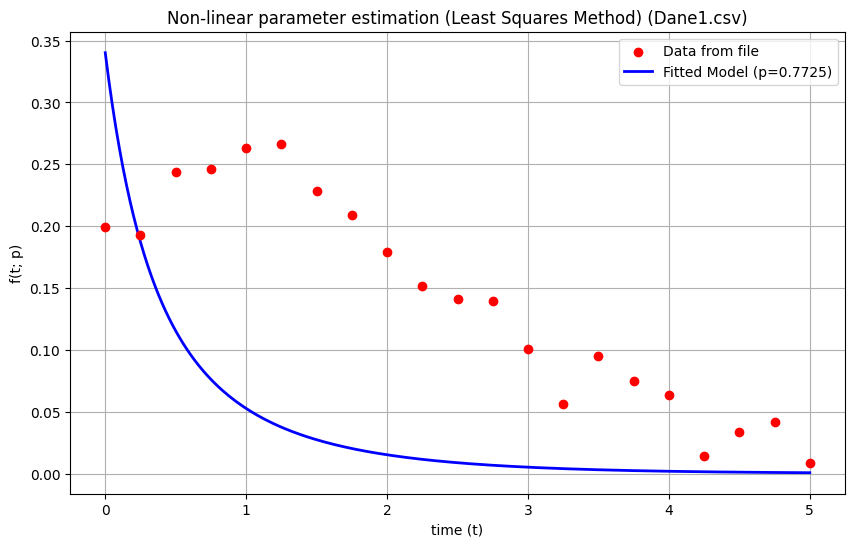

In [7]:
plt.figure(figsize=(10, 6))

# empirical data scatter plot
plt.scatter(df['czas'], df['Dane'], color='red', label='Data from file', zorder=5)

# fitted theoretical model line plot
t_linia = np.linspace(df['czas'].min(), df['czas'].max(), 200)
plt.plot(t_linia, f_model(t_linia, p_optimal), color='blue', 
         label=f'Fitted Model (p={p_optimal:.4f})', linewidth=2)

plt.xlabel('time (t)')
plt.ylabel('f(t; p)')
plt.title('Non-linear parameter estimation (Least Squares Method) (Dane1.csv)')
plt.legend()
plt.grid(True)
plt.show()